<a href="https://colab.research.google.com/github/NisalJayaweera/EN3160-Assignment-1-on-Intensity-Transformations-and-Neighborhood-Filtering/blob/main/Intensity_Transformation_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EN3160 Assignment 1 on Intensity Transformations and Neighborhood Filtering.

**230300C - Jayaweera N.S.**

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import img_as_ubyte
from skimage.color import rgb2gray
from skimage.io import imread

**1**

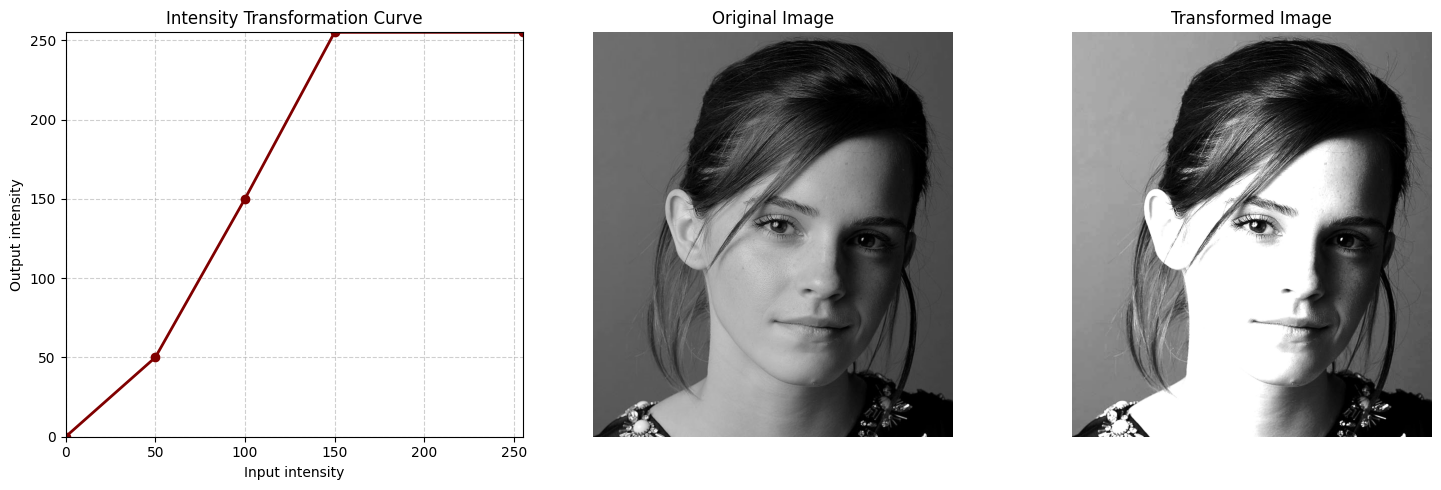

In [20]:
def intensity_transform(im, breakpoints):
    im_float = im.astype(float)
    out = np.zeros_like(im_float)

    breakpoints = breakpoints[np.argsort(breakpoints[:, 0])]

    for i in range(len(breakpoints) - 1):
        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i+1]

        if x1 == x2:
            continue

        mask = (im_float >= x1) & (im_float <= x2)
        out[mask] = y1 + (y2 - y1) * (im_float[mask] - x1) / (x2 - x1)

    out[im_float < breakpoints[0, 0]] = breakpoints[0, 1]
    out[im_float > breakpoints[-1, 0]] = breakpoints[-1, 1]

    return np.clip(out, 0, 255).astype(np.uint8)

image_path = '/images/q1.jpeg'
#try:
original_im = rgb2gray(imread(image_path))
original_im = img_as_ubyte(original_im)
#except FileNotFoundError:

    #original_im = np.tile(np.linspace(0, 255, 256, dtype=np.uint8), (256, 1))

breakpoints = np.array([
    [0, 0],
    [50, 50],
    [100, 150],
    [150, 255],
    [255, 255]
])

transformed_im = intensity_transform(original_im, breakpoints)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

xp = breakpoints[:, 0]
fp = breakpoints[:, 1]
axes[0].plot(xp, fp, color='maroon', linewidth=2, marker='o')
axes[0].set_title('Intensity Transformation Curve')
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_xlim([0, 255])
axes[0].set_ylim([0, 255])
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].imshow(original_im, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Original Image')
axes[1].axis('off')

axes[2].imshow(transformed_im, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Transformed Image')
axes[2].axis('off')

plt.tight_layout()
plt.show()